# Credit Card Loan Recommendation Classification

Borrowers often use personal loans to consolidate high-interest credit card balances into a structured installment loan. In that setting, a lender needs a simple first-pass screening approach to separate applications that should move forward for consideration from applications that should be held back for closer review.

This notebook studies that screening problem using public LendingClub data. Because the dataset does not contain an explicit historical recommendation field, the project defines a proxy target from resolved outcomes:
- `consider`: loans that were fully paid
- `hold`: loans that ended in default-like outcomes


## Problem Statement

When a borrower applies for a loan with the purpose `credit_card`, can origination-time borrower and loan attributes be used to support an initial recommendation of `consider` or `hold`?

The business goal is not fully automated approval. The goal is a clear, data-driven screening model that can help prioritize which credit-card debt-consolidation cases deserve further attention.


## Data Source and Scope

Dataset used:
- LendingClub accepted loans dataset from Kaggle
- Dataset page: [Kaggle: Lending Club](https://www.kaggle.com/datasets/wordsforthewise/lending-club)
- File used in this notebook: `accepted_2007_to_2018Q4.csv.gz`

Why this dataset is appropriate:
- it is a large public consumer-lending dataset
- it includes origination-time borrower and loan attributes
- it includes final loan outcomes needed to construct the proxy target

Scope used in this notebook:
- only accepted loans
- only `purpose == "credit_card"`
- only resolved loan statuses

Resolved statuses retained:
- `Fully Paid`
- `Charged Off`
- `Default`
- `Does not meet the credit policy. Status:Charged Off`

Target definition:
- `consider` for `Fully Paid`
- `hold` for default-like outcomes

Unit of analysis:
- each row represents one accepted LendingClub loan


## 1) Imports and Paths

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "data").exists() else NOTEBOOK_DIR.parent
REPORT_DIR = REPO_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

DATA_FILE = REPO_ROOT / "data" / "raw" / "lending_club" / "accepted_2007_to_2018Q4.csv.gz"
ALT_DATA_FILE = REPO_ROOT / "data" / "raw" / "lending_club" / "accepted_2007_to_2018q4.csv" / "accepted_2007_to_2018Q4.csv"
if not DATA_FILE.exists() and ALT_DATA_FILE.exists():
    DATA_FILE = ALT_DATA_FILE
if not DATA_FILE.exists():
    fallback_candidates = [
        REPO_ROOT.parent / "loan-refinance-intelligence-backup" / "data" / "raw" / "lending_club" / "accepted_2007_to_2018Q4.csv.gz",
        REPO_ROOT.parent / "loan-recommendation-classification" / "data" / "raw" / "lending_club" / "accepted_2007_to_2018Q4.csv.gz",
    ]
    for fallback_file in fallback_candidates:
        if fallback_file.exists():
            DATA_FILE = fallback_file
            break

MAX_MODEL_ROWS = int(os.getenv("PROJECT_MAX_ROWS", "20000"))
CV_SPLITS = int(os.getenv("PROJECT_CV_SPLITS", "3"))
RANDOM_STATE = 42

print(f"Dataset file name: {DATA_FILE.name if DATA_FILE.exists() else 'missing'}")
print(f"Dataset available: {DATA_FILE.exists()}")
print(f"Maximum modeling sample size: {MAX_MODEL_ROWS}")
print(f"Cross-validation folds: {CV_SPLITS}")


Dataset file name: accepted_2007_to_2018Q4.csv.gz
Dataset available: True
Maximum modeling sample size: 20000
Cross-validation folds: 3


## 2) Load and Filter LendingClub Data

In [2]:
if not DATA_FILE.exists():
    raise FileNotFoundError("Place the LendingClub accepted loans file under data/raw/lending_club/ before running this notebook.")

resolved_statuses = {
    "Fully Paid",
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off",
}

selected_columns = [
    "id",
    "loan_status",
    "purpose",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "annual_inc",
    "dti",
    "revol_util",
    "fico_range_low",
    "fico_range_high",
    "delinq_2yrs",
    "open_acc",
]

header = pd.read_csv(DATA_FILE, nrows=0, low_memory=False)
usecols = [c for c in selected_columns if c in header.columns]

chunks = []
for chunk in pd.read_csv(DATA_FILE, usecols=usecols, chunksize=250000, low_memory=False):
    mask = chunk["purpose"].eq("credit_card") & chunk["loan_status"].isin(resolved_statuses)
    filtered = chunk.loc[mask].copy()
    if not filtered.empty:
        chunks.append(filtered)

df = pd.concat(chunks, ignore_index=True)
print(f"Filtered rows before dedupe/sample: {len(df):,}")
display(df.head())


Filtered rows before dedupe/sample: 295,354


,id,term,int_rate,installment,grade,sub_grade,annual_inc,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,revol_util
0,68466926,36 months,6.49,306.45,A,A2,85000.0,Fully Paid,credit_card,13.07,0.0,685.0,689.0,14.0,34.5
1,68616873,36 months,11.48,263.74,B,B5,42000.0,Fully Paid,credit_card,34.80,0.0,700.0,704.0,8.0,39.1
2,68354783,36 months,7.49,298.58,A,A4,60000.0,Fully Paid,credit_card,22.44,0.0,695.0,699.0,7.0,59.4
3,68009401,60 months,14.85,379.39,C,C5,48000.0,Fully Paid,credit_card,33.18,0.0,685.0,689.0,11.0,29.6
4,68436666,36 months,13.44,169.54,C,C3,79000.0,Fully Paid,credit_card,12.70,0.0,665.0,669.0,3.0,101.5


## 3) Data Cleaning and Feature Engineering

In [3]:
def to_numeric_percent(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.replace("%", "", regex=False).str.strip()
    return pd.to_numeric(cleaned, errors="coerce")

df["recommendation_label"] = np.where(df["loan_status"].eq("Fully Paid"), "consider", "hold")
df["int_rate_num"] = to_numeric_percent(df["int_rate"])
df["revol_util_num"] = to_numeric_percent(df["revol_util"])
df["fico_avg"] = (
    pd.to_numeric(df["fico_range_low"], errors="coerce")
    + pd.to_numeric(df["fico_range_high"], errors="coerce")
) / 2.0
df["term_months"] = pd.to_numeric(df["term"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")
df["annual_inc_log1p"] = np.log1p(pd.to_numeric(df["annual_inc"], errors="coerce").clip(lower=0))
monthly_income = (pd.to_numeric(df["annual_inc"], errors="coerce") / 12.0).clip(lower=1.0)
df["installment_to_monthly_income"] = pd.to_numeric(df["installment"], errors="coerce") / monthly_income

duplicate_rows = int(df["id"].duplicated().sum()) if "id" in df.columns else int(df.duplicated().sum())
if "id" in df.columns:
    df = df.drop_duplicates(subset=["id"], keep="first")
else:
    df = df.drop_duplicates(keep="first")

if len(df) > MAX_MODEL_ROWS:
    df = df.sample(n=MAX_MODEL_ROWS, random_state=RANDOM_STATE)

df = df.reset_index(drop=True)
print(f"Rows after dedupe/sample: {len(df):,}")
print(f"Duplicate rows removed: {duplicate_rows:,}")
display(df.head())


Rows after dedupe/sample: 20,000
Duplicate rows removed: 0


,id,term,int_rate,installment,grade,sub_grade,annual_inc,loan_status,purpose,dti,delinq_2yrs,fico_range_low,fico_range_high,open_acc,revol_util,recommendation_label,int_rate_num,revol_util_num,fico_avg,term_months,annual_inc_log1p,installment_to_monthly_income
0,75221661,36 months,11.99,478.22,C,C1,59000.0,Fully Paid,credit_card,17.98,0.0,670.0,674.0,7.0,10.7,consider,11.99,10.7,672.0,36,10.985310,0.097265
1,1487483,36 months,14.09,747.74,B,B5,55000.0,Fully Paid,credit_card,21.86,0.0,695.0,699.0,5.0,70.9,consider,14.09,70.9,697.0,36,10.915107,0.163143
2,55451272,36 months,11.53,148.46,B,B5,19000.0,Fully Paid,credit_card,25.90,0.0,665.0,669.0,5.0,87.1,consider,11.53,87.1,667.0,36,9.852247,0.093764
3,7956313,36 months,20.20,745.32,D,D5,80000.0,Fully Paid,credit_card,17.88,0.0,670.0,674.0,13.0,64.0,consider,20.20,64.0,672.0,36,11.289794,0.111798
4,134914565,36 months,6.19,884.74,A,A2,62000.0,Fully Paid,credit_card,27.33,0.0,735.0,739.0,19.0,31.7,consider,6.19,31.7,737.0,36,11.034906,0.171240


## 4) Missingness and Outlier Checks

This section documents the main data-quality steps used before modeling:
- inspect missing values
- impute numeric columns with the median and categorical columns with the mode
- summarize potential outliers with the IQR rule


In [4]:
model_df = df.copy()

numeric_features = [
    "int_rate_num",
    "annual_inc",
    "annual_inc_log1p",
    "dti",
    "revol_util_num",
    "installment",
    "fico_avg",
    "delinq_2yrs",
    "open_acc",
    "term_months",
    "installment_to_monthly_income",
]
categorical_features = ["grade", "sub_grade"]

missing_before = (
    model_df[numeric_features + categorical_features]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("missing_pct_before")
    .rename_axis("feature").reset_index()
)

for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")
    model_df[col] = model_df[col].fillna(model_df[col].median())

for col in categorical_features:
    mode = model_df[col].mode(dropna=True)
    model_df[col] = model_df[col].fillna(mode.iloc[0] if not mode.empty else "unknown")

missing_after = (
    model_df[numeric_features + categorical_features]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct_after")
    .rename_axis("feature").reset_index()
)

missing_summary = missing_before.merge(missing_after, on="feature")
display(missing_summary)

outlier_rows = []
for col in ["annual_inc", "dti", "revol_util_num", "installment", "fico_avg"]:
    series = pd.to_numeric(model_df[col], errors="coerce").dropna()
    q1 = float(series.quantile(0.25))
    q3 = float(series.quantile(0.75))
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    outlier_rows.append(
        {
            "feature": col,
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "outlier_pct": round(float(mask.mean() * 100), 2),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows).sort_values("outlier_pct", ascending=False)
display(outlier_summary)


,feature,missing_pct_before,missing_pct_after
0,dti,0.03,0.0
1,revol_util_num,0.02,0.0
2,int_rate_num,0.00,0.0
3,annual_inc,0.00,0.0
4,annual_inc_log1p,0.00,0.0
5,installment,0.00,0.0
6,fico_avg,0.00,0.0
7,delinq_2yrs,0.00,0.0
8,open_acc,0.00,0.0
9,term_months,0.00,0.0


,feature,q1,q3,iqr,outlier_pct
0,annual_inc,46000.00,92000.00,46000.00,4.42
3,installment,262.13,583.58,321.45,3.08
4,fico_avg,672.00,712.00,40.00,2.27
1,dti,12.09,24.08,11.99,0.35
2,revol_util_num,39.00,73.60,34.60,0.01


## 5) Exploratory Data Analysis

,recommendation_label,count,pct
0,consider,16658,83.29
1,hold,3342,16.71


int_rate_num        annual_inc             dti        fico_avg        revol_util_num       
                             mean median       mean   median   mean median     mean median           mean median
recommendation_label                                                                                            
consider                    11.34  10.99   78637.77  65000.0  17.96  17.24   698.65  692.0           55.4   56.0
hold                        14.06  13.59   67592.05  58989.5  20.46  20.03   688.39  682.0           58.6   59.0

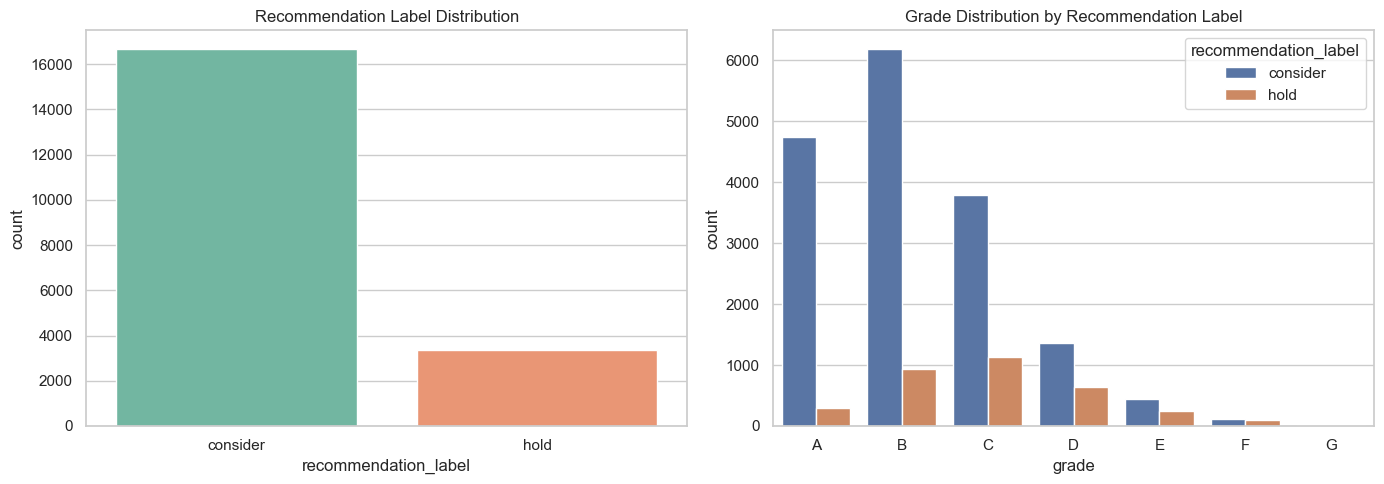

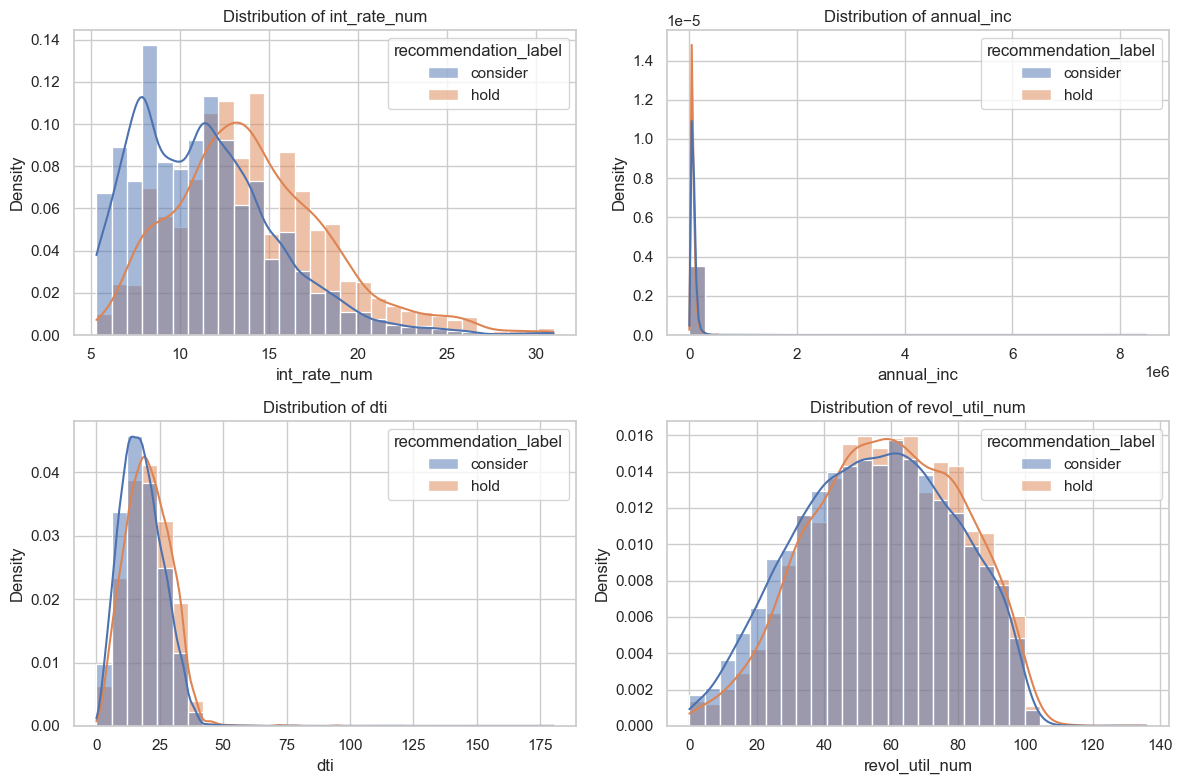

,int_rate_num,annual_inc,dti,revol_util_num,fico_avg,installment,term_months
int_rate_num,1.00,-0.08,0.21,0.27,-0.41,0.12,0.43
annual_inc,-0.08,1.00,-0.14,0.05,0.05,0.28,0.03
dti,0.21,-0.14,1.00,0.13,-0.04,0.07,0.10
revol_util_num,0.27,0.05,0.13,1.00,-0.43,0.18,0.10
fico_avg,-0.41,0.05,-0.04,-0.43,1.00,0.06,-0.02
installment,0.12,0.28,0.07,0.18,0.06,1.00,0.10
term_months,0.43,0.03,0.10,0.10,-0.02,0.10,1.00


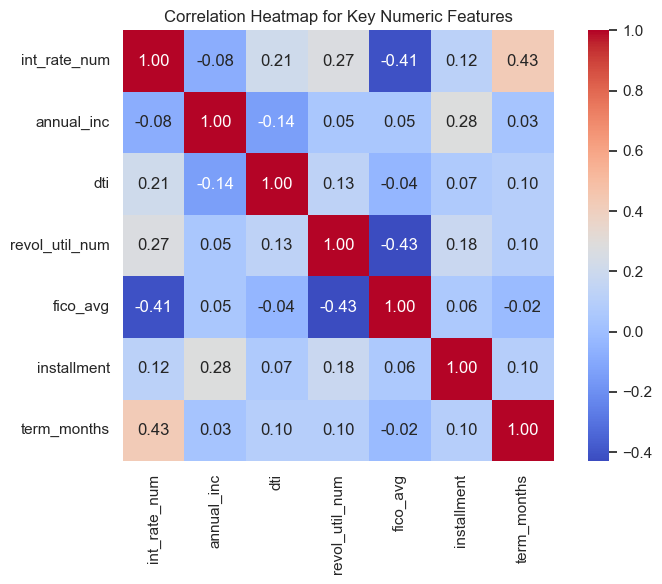

In [5]:
label_summary = (
    model_df["recommendation_label"].value_counts()
    .rename_axis("recommendation_label")
    .reset_index(name="count")
)
label_summary["pct"] = (label_summary["count"] / len(model_df) * 100).round(2)
display(label_summary)
label_summary.to_csv(REPORT_DIR / "label_summary.csv", index=False)

descriptive_summary = (
    model_df.groupby("recommendation_label")[["int_rate_num", "annual_inc", "dti", "fico_avg", "revol_util_num"]]
    .agg(["mean", "median"])
    .round(2)
)
display(descriptive_summary)
descriptive_summary.to_csv(REPORT_DIR / "descriptive_summary_by_label.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=model_df, x="recommendation_label", order=["consider", "hold"], ax=axes[0], palette="Set2", hue="recommendation_label", legend=False)
axes[0].set_title("Recommendation Label Distribution")
axes[0].set_xlabel("recommendation_label")

grade_plot = model_df.groupby(["grade", "recommendation_label"]).size().reset_index(name="count")
sns.barplot(data=grade_plot, x="grade", y="count", hue="recommendation_label", ax=axes[1])
axes[1].set_title("Grade Distribution by Recommendation Label")
axes[1].set_xlabel("grade")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_balance_and_grade_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

plot_cols = ["int_rate_num", "annual_inc", "dti", "revol_util_num"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, plot_cols):
    sns.histplot(data=model_df, x=col, hue="recommendation_label", bins=30, kde=True, ax=ax, stat="density", common_norm=False)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

correlation_features = ["int_rate_num", "annual_inc", "dti", "revol_util_num", "fico_avg", "installment", "term_months"]
correlation_matrix = model_df[correlation_features].corr().round(2)
display(correlation_matrix)
correlation_matrix.to_csv(REPORT_DIR / "feature_correlation_matrix.csv")

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap for Key Numeric Features")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 6) Modeling Strategy

Prediction target used for modeling:
- `hold` is encoded as the positive class (`1`)
- `consider` is encoded as the negative class (`0`)

Why this encoding is useful:
- `hold` is the riskier outcome and the harder class to catch
- precision and recall become easier to interpret from a screening perspective
- a strong model should help identify which applications deserve closer review before moving forward

Modeling approach used in this notebook:
- hold out a test set for final evaluation
- compare multiple baseline classifiers with cross-validation on the training set
- tune each model with a small `GridSearchCV`
- select the final model based on cross-validated ROC-AUC


In [6]:
X = model_df[numeric_features + categorical_features].copy()
y = (model_df["recommendation_label"] == "hold").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            categorical_features,
        ),
    ]
)

cv_strategy = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

baseline_models = {
    "logistic_regression": Pipeline([
        ("prep", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")),
    ]),
    "decision_tree": Pipeline([
        ("prep", preprocessor),
        ("model", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(class_weight="balanced_subsample", random_state=RANDOM_STATE, n_jobs=1)),
    ]),
}

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Positive-class rate in training data (hold): {y_train.mean():.3f}")


Training rows: 16,000
Test rows: 4,000
Positive-class rate in training data (hold): 0.167


## 7) Baseline Model Comparison with Cross-Validation

The first comparison uses untuned baseline models on the training split only. This gives a fair starting point before hyperparameter tuning and helps show whether a more complex model is materially better than a simpler baseline.

Primary selection metric:
- `ROC-AUC`

Why `ROC-AUC` is the primary metric here:
- it evaluates ranking quality across thresholds
- it is appropriate for imbalanced binary classification
- it does not force the analysis to commit to one operating threshold too early

Supporting metrics:
- `precision`, `recall`, and `F1` for the positive `hold` class


In [7]:
baseline_rows = []
for model_name, pipeline in baseline_models.items():
    cv_result = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    baseline_rows.append({
        "model": model_name,
        "cv_roc_auc_mean": round(cv_result["test_roc_auc"].mean(), 4),
        "cv_precision_mean": round(cv_result["test_precision"].mean(), 4),
        "cv_recall_mean": round(cv_result["test_recall"].mean(), 4),
        "cv_f1_mean": round(cv_result["test_f1"].mean(), 4),
    })

baseline_results = pd.DataFrame(baseline_rows).sort_values("cv_roc_auc_mean", ascending=False)
display(baseline_results)
baseline_results.to_csv(REPORT_DIR / "baseline_cv_results.csv", index=False)


,model,cv_roc_auc_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean
0,logistic_regression,0.7108,0.2705,0.6601,0.3836
2,random_forest,0.6828,0.4119,0.0355,0.0649
1,decision_tree,0.5417,0.2348,0.2405,0.2376


## 8) Hyperparameter Tuning with Grid Search

A small grid search is used for each model family. The aim is not exhaustive optimization; the aim is to show a disciplined and interpretable tuning process that improves the comparison without making the notebook difficult to follow.


In [8]:
param_grids = {
    "logistic_regression": {
        "model__C": [0.3, 1.0, 3.0],
        "model__penalty": ["l1", "l2"],
    },
    "decision_tree": {
        "model__max_depth": [4, 8, None],
        "model__min_samples_leaf": [20, 50],
        "model__criterion": ["gini", "entropy"],
    },
    "random_forest": {
        "model__n_estimators": [150],
        "model__max_depth": [8, 12],
        "model__min_samples_leaf": [10, 30],
    },
}

search_rows = []
search_objects = {}
for model_name, pipeline in baseline_models.items():
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[model_name],
        scoring="roc_auc",
        cv=cv_strategy,
        n_jobs=1,
        refit=True,
    )
    search.fit(X_train, y_train)
    search_objects[model_name] = search
    search_rows.append({
        "model": model_name,
        "best_cv_roc_auc": round(search.best_score_, 4),
        "best_params": str(search.best_params_),
    })

search_summary = pd.DataFrame(search_rows).sort_values("best_cv_roc_auc", ascending=False)
display(search_summary)
search_summary.to_csv(REPORT_DIR / "grid_search_summary.csv", index=False)

selected_model_name = search_summary.iloc[0]["model"]
selected_search = search_objects[selected_model_name]
print(f"Selected model from cross-validated ROC-AUC: {selected_model_name}")
print(f"Best parameters: {selected_search.best_params_}")


,model,best_cv_roc_auc,best_params
0,logistic_regression,0.7110,"{'model__C': 1.0, 'model__penalty': 'l1'}"
2,random_forest,0.7084,"{'model__max_depth': 12, 'model__min_samples_l..."
1,decision_tree,0.6876,"{'model__criterion': 'entropy', 'model__max_de..."


Selected model from cross-validated ROC-AUC: logistic_regression
Best parameters: {'model__C': 1.0, 'model__penalty': 'l1'}


## 9) Final Test-Set Evaluation

Only after cross-validation and grid search are complete do we evaluate the tuned models on the holdout test set. This keeps model selection and final performance assessment separate.


,model,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1
0,logistic_regression,0.7032,0.2951,0.2716,0.6916,0.3900
2,random_forest,0.6957,0.2933,0.2736,0.6063,0.3771
1,decision_tree,0.6751,0.2595,0.2548,0.6931,0.3726


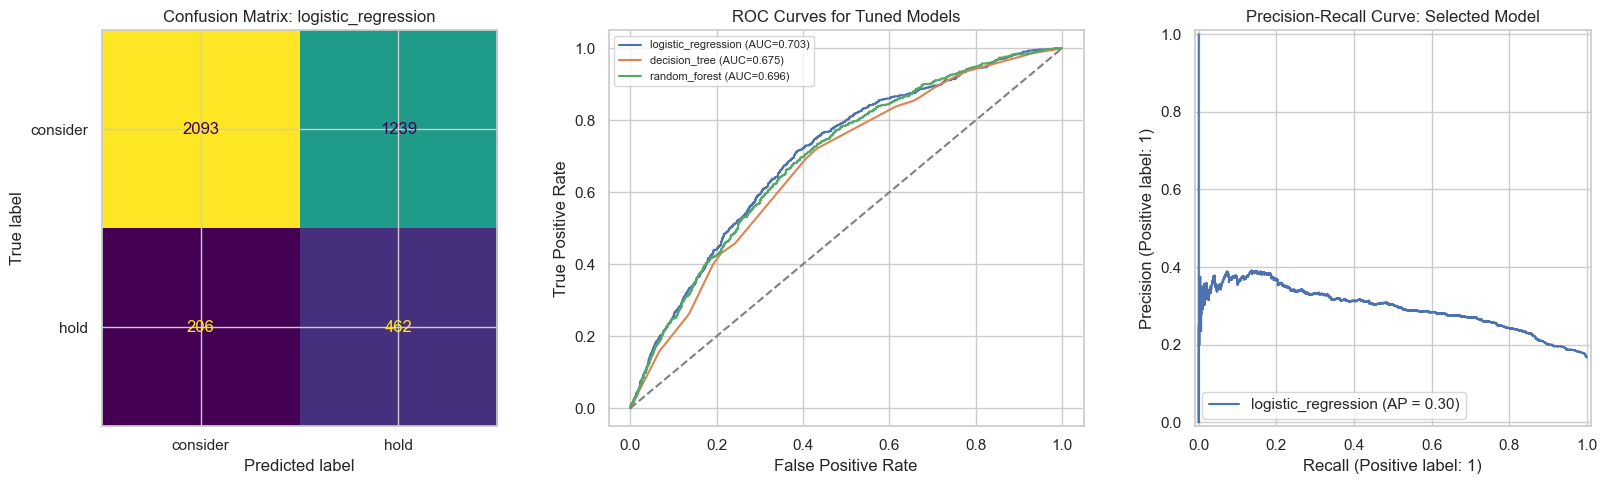

,feature,coefficient,abs_coefficient
17,cat__grade_G,1.890350,1.890350
16,cat__grade_F,1.702868,1.702868
11,cat__grade_A,-1.609337,1.609337
15,cat__grade_E,1.156706,1.156706
52,cat__sub_grade_G5,1.045754,1.045754
18,cat__sub_grade_A1,-0.933411,0.933411
47,cat__sub_grade_F5,0.929038,0.929038
14,cat__grade_D,0.758282,0.758282
12,cat__grade_B,-0.755571,0.755571
49,cat__sub_grade_G2,0.725036,0.725036


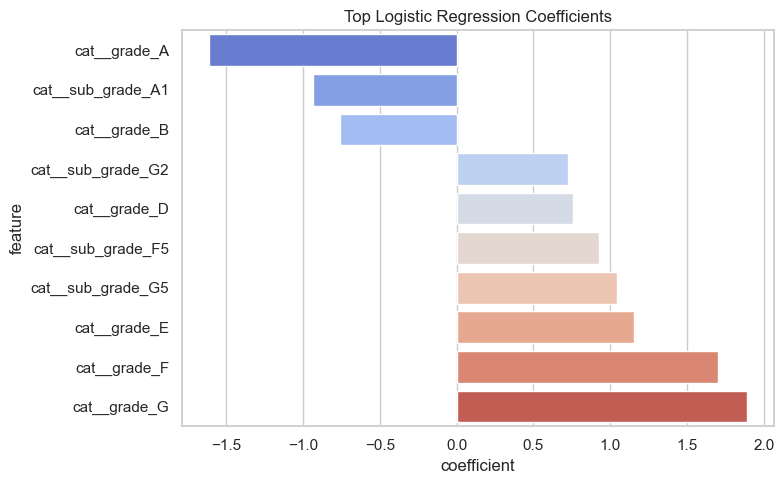

In [9]:
final_rows = []
selected_model = selected_search.best_estimator_
selected_model_proba = None
selected_model_pred = None

for model_name, search in search_objects.items():
    estimator = search.best_estimator_
    proba = estimator.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    final_rows.append({
        "model": model_name,
        "test_roc_auc": round(roc_auc_score(y_test, proba), 4),
        "test_pr_auc": round(average_precision_score(y_test, proba), 4),
        "test_precision": round(precision_score(y_test, pred), 4),
        "test_recall": round(recall_score(y_test, pred), 4),
        "test_f1": round(f1_score(y_test, pred), 4),
    })
    if model_name == selected_model_name:
        selected_model_proba = proba
        selected_model_pred = pred

final_results = pd.DataFrame(final_rows).sort_values("test_roc_auc", ascending=False)
display(final_results)
final_results.to_csv(REPORT_DIR / "final_test_results.csv", index=False)
final_results.to_csv(REPORT_DIR / "model_results.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, selected_model_pred), display_labels=["consider", "hold"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f"Confusion Matrix: {selected_model_name}")

for model_name, search in search_objects.items():
    estimator = search.best_estimator_
    proba = estimator.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[1].plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curves for Tuned Models")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)

PrecisionRecallDisplay.from_predictions(y_test, selected_model_proba, ax=axes[2], name=selected_model_name)
axes[2].set_title("Precision-Recall Curve: Selected Model")

plt.tight_layout()
plt.savefig(FIG_DIR / "model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

logistic_model = search_objects["logistic_regression"].best_estimator_
logistic_feature_names = logistic_model.named_steps["prep"].get_feature_names_out()
logistic_coefficients = logistic_model.named_steps["model"].coef_[0]
coefficient_summary = pd.DataFrame({
    "feature": logistic_feature_names,
    "coefficient": logistic_coefficients,
})
coefficient_summary["abs_coefficient"] = coefficient_summary["coefficient"].abs()
coefficient_summary = coefficient_summary.sort_values("abs_coefficient", ascending=False)
display(coefficient_summary.head(10))
coefficient_summary.to_csv(REPORT_DIR / "logistic_coefficients.csv", index=False)

plt.figure(figsize=(8, 5))
plot_df = coefficient_summary.head(10).sort_values("coefficient")
sns.barplot(data=plot_df, x="coefficient", y="feature", hue="feature", palette="coolwarm", legend=False)
plt.title("Top Logistic Regression Coefficients")
plt.tight_layout()
plt.savefig(FIG_DIR / "top_logistic_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


## 10) Findings and Recommendations

Key findings from the current run:
- The filtered source universe contains `295,354` resolved `credit_card` loans, and the modeling workflow uses a `20,000` row sample for faster iteration.
- The `hold` class represents `16.71%` of the sampled data, so the modeling task is moderately imbalanced.
- Descriptive analysis shows that `hold` cases tend to have higher average interest rates (`14.06%` vs `11.34%`), higher debt-to-income ratios (`20.46` vs `17.96`), lower average FICO (`688.39` vs `698.65`), and lower annual income (`$67.6k` vs `$78.6k`) than `consider` cases.

Model comparison summary:
- Logistic Regression achieved the strongest cross-validated ROC-AUC (`0.7110`) and remained the top model on the test set (`0.7032`).
- Random Forest was competitive on ROC-AUC (`0.7084` in cross-validation, `0.6957` on the test set) but did not outperform Logistic Regression.
- Decision Tree was the weakest of the three models and is not the preferred final model.

Interpretation for the screening use case:
- The selected Logistic Regression model achieves `recall = 0.6916` for the positive `hold` class, meaning it catches about 69% of the applications that should likely be held back for closer review.
- Its `precision = 0.2716` means the flagged `hold` cases still require manual review; the model is more useful for triage than for automatic rejection.
- The strongest logistic coefficients are concentrated in credit-risk grade variables, which is consistent with lending-domain expectations: higher-risk grades push the prediction toward `hold`, while stronger grades push the prediction toward `consider`.

Recommendation:
- Use Logistic Regression as the final baseline model for this project because it offers the best balance of performance, interpretability, and ease of explanation.
- Position the output as a first-pass recommendation tool to prioritize review, not as a replacement for full underwriting or credit policy.
